In [1]:
from pathlib import Path
import json
from collections import Counter
import matplotlib.pyplot as plt

# Adjust this base path if your notebook's working directory differs
BASE = Path('..') / 'Data' / 'mtsd_fully_annotated_annotation' / 'mtsd_v2_fully_annotated'
TRAIN_SPLIT = BASE / 'splits' / 'train.txt'
ANN_DIR = BASE / 'annotations'

# Read train IDs (one id per line)
ids = [l.strip() for l in TRAIN_SPLIT.read_text().splitlines() if l.strip()]

def extract_labels(ann):
    """Try several common annotation shapes and return list of label names.
    Works for files that contain keys like 'annotations', 'objects', 'regions',
    and will map numeric category ids via a local 'categories' list if present.
    """
    labels = []
    if not isinstance(ann, dict):
        return labels
    # build category id -> name map if available
    cat_map = {}
    if 'categories' in ann and isinstance(ann['categories'], list):
        for c in ann['categories']:
            if isinstance(c, dict):
                cid = c.get('id')
                name = c.get('name') or c.get('label')
                if cid is not None and name is not None:
                    cat_map[cid] = name
    # common container keys
    for key in ('annotations','objects','regions','instances','labels'):
        if key in ann and isinstance(ann[key], list):
            for obj in ann[key]:
                if not isinstance(obj, dict):
                    continue
                # prefer readable label fields
                for k in ('label','category','category_name','class','name'):
                    if k in obj:
                        val = obj[k]
                        if isinstance(val, int):
                            labels.append(str(cat_map.get(val, val)))
                        else:
                            labels.append(str(val))
                        break
                else:
                    cid = obj.get('category_id') or obj.get('categoryId')
                    if cid is not None:
                        labels.append(str(cat_map.get(cid, cid)))
            if labels:
                return labels
    # fallback: scan top-level values for lists of objects
    for v in ann.values():
        if isinstance(v, list):
            for item in v:
                if isinstance(item, dict):
                    for k in ('label','category','name'):
                        if k in item:
                            labels.append(str(item[k]))
            if labels:
                return labels
    return labels

counter = Counter()
missing = 0
for id_ in ids:
    p = ANN_DIR / f"{id_}.json"
    if not p.exists():
        missing += 1
        continue
    try:
        data = json.loads(p.read_text())
    except Exception:
        continue
    labels = extract_labels(data)
    # some annotation files store a single top-level 'label' or 'category'
    if not labels:
        if isinstance(data, dict):
            for k in ('label','category','class','name'):
                if k in data:
                    labels.append(str(data[k]))
    counter.update(labels)


Parsed 36589 annotation files, 0 missing.


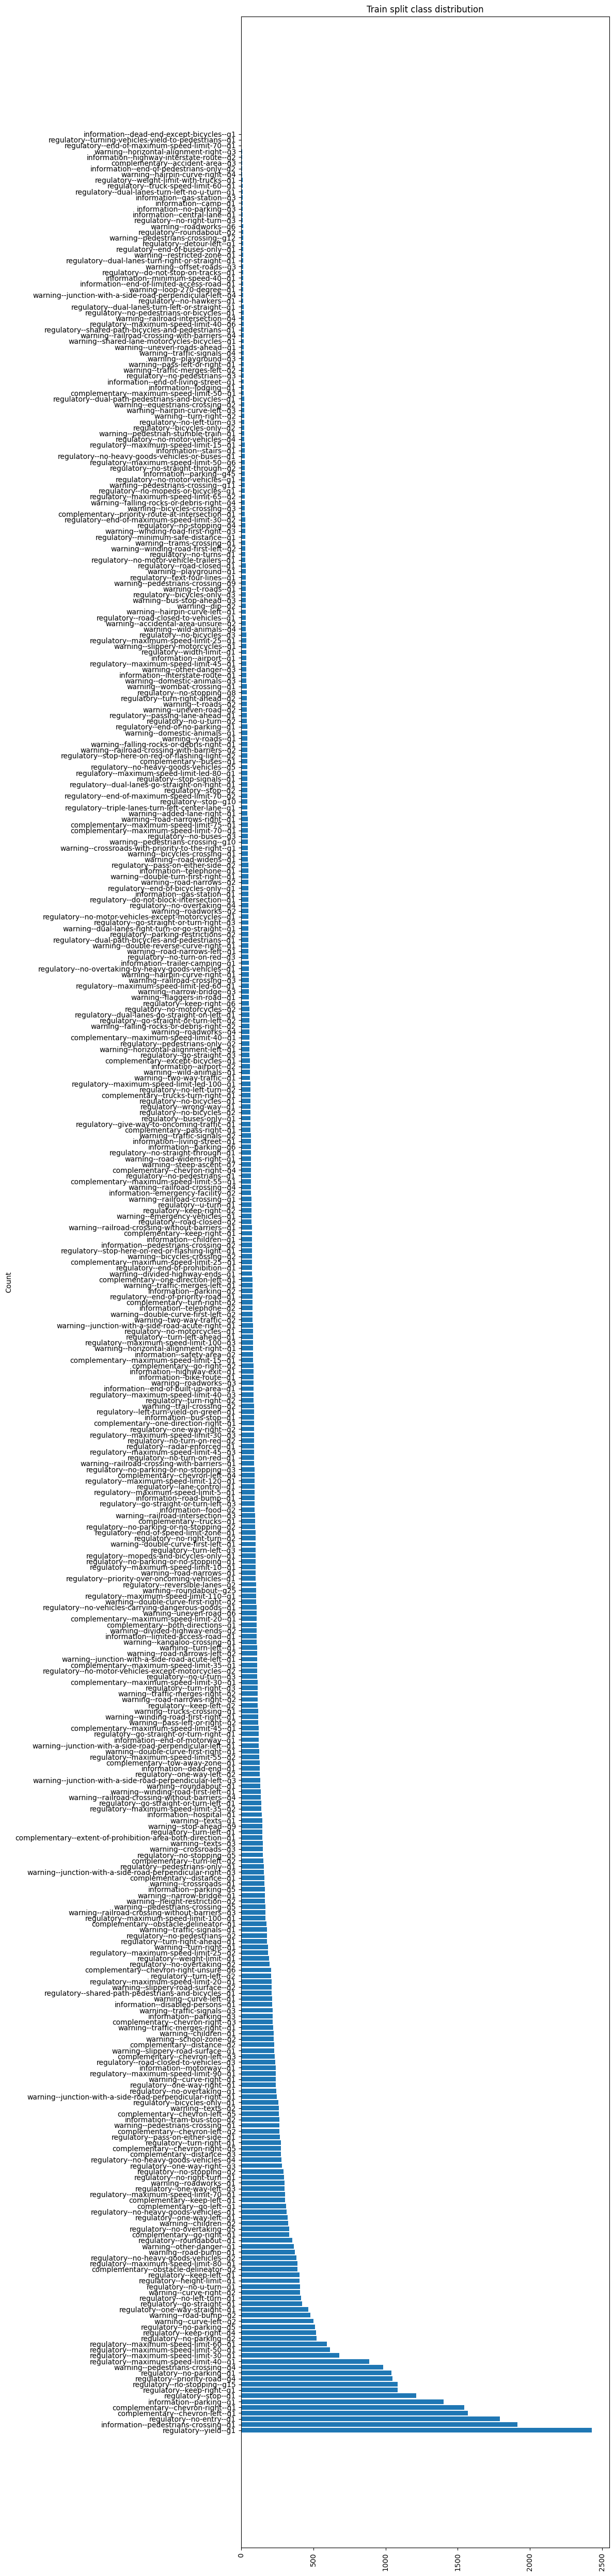

In [2]:
print(f'Parsed {len(ids)-missing} annotation files, {missing} missing.')
if not counter:
    print('No labels found — adapt parser for your annotation schema.')
else:
    items = counter.most_common()
    labels, counts = zip(*items)
    plt.figure(figsize=(12,50))
    plt.barh(labels[1:], counts[1:], color='C0',)
    plt.xticks(rotation=90)
    plt.ylabel('Count')
    plt.title('Train split class distribution')
    plt.tight_layout()
    plt.show()

In [3]:
import pandas as pd
data = pd.DataFrame({
    'labels':labels,
    'counts':counts
})


In [4]:
data.to_csv('Data_summary.csv', index=False)